In [1]:
import radvel
import numpy as np
import matplotlib.pyplot as plt
from dace_query.spectroscopy import Spectroscopy
from scipy.optimize import least_squares
from astropy import units as u
from astropy import constants as const
from astroquery.mast import Catalogs

2026-08-19 21:15:23,023 - WARNING - File .dacerc not found. You are requesting data in public mode. To change this behaviour, create a .dacerc file in your home directory and fill it with your API key. More infos on https://dace.unige.ch


TIC 266980320 - rv_ts['HARPS15']['DRS-3.3.6-CCF']['HARPS']

In [15]:
input_catalog = input('TIC ID: ')
star = Catalogs.query_object(input_catalog, catalog = 'TIC')

#results from lightkurve project:
period = 6.03456949 
inclination = 86.30815871
radius = 4.42282221

TIC ID:  TIC 266980320


Text(0.5, 1.0, 'Observed RV')

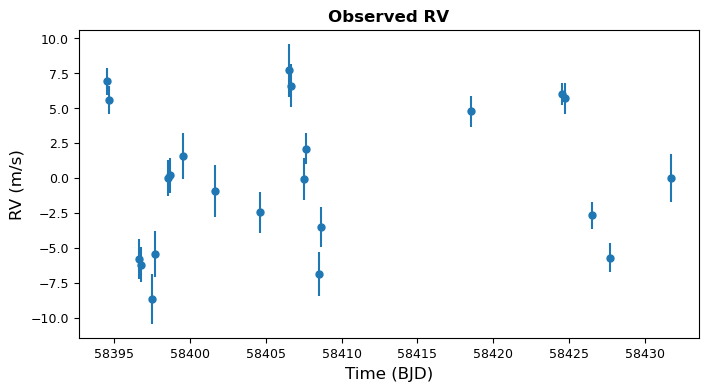

In [12]:
def plot_rv(time_array):
    fig, ax = plt.subplots(figsize = (8,4))
    ax.errorbar(time_array, rv_norm, rv_err, fmt= 'o')
    ax.set_xlabel('Time (BJD)', fontsize = 12)
    ax.set_ylabel('RV (m/s)', fontsize = 12)

def import_data():
    rv_ts = Spectroscopy.get_timeseries(input_catalog, sorted_by_instrument = True)
    rv_data = rv_ts['HARPS15']['DRS-3.3.6-CCF']['HARPS']
    time, rv, rv_err = rv_data['rjd'], rv_data['rv'], rv_data['rv_err'] 
    rv_norm = (rv - np.median(rv))    
    sigma2 = 2*np.std(rv_norm)    
    
    i = 0 
    while i < len(rv_norm):
        if (rv_norm[i] > sigma2) or (rv_norm[i] < -sigma2):
            time = np.delete(time, i)
            rv_norm = np.delete(rv_norm, i)
            rv_err = np.delete(rv_err, i)
        i += 1
    return input_catalog, time, rv_norm, rv_err

input_catalog, time, rv_norm, rv_err = import_data()
plot_rv(time)
plt.title('Observed RV', fontsize = 12, fontweight = 'bold')

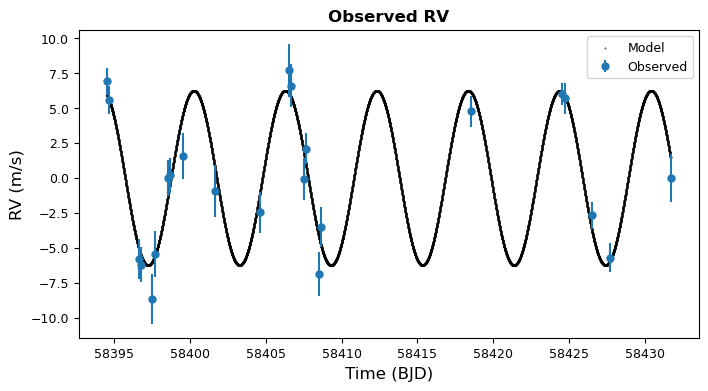

In [7]:
def initial_estimates():
    k_est = np.std(rv_norm)
    t0_est = 0
    estimates = [k_est, t0_est]
    return estimates

def rv_model(x, period):
    true_anomaly = radvel.orbit.true_anomaly(time, x[1], period, 0)
    modeled = x[0]*np.cos(true_anomaly+(np.pi/2))
    return modeled
    
def calc_residuals(x, period):
    observed = rv_norm
    observed_error = rv_err
    modeled = rv_model(x, period)
    
    residuals = (observed-modeled)/observed_error
    return residuals

def final_model():
    model_x = np.linspace(np.min(time), np.max(time), 10000)
    true_anomaly = radvel.orbit.true_anomaly(model_x, t0, period, 0)
    model_y = k*np.cos(true_anomaly+(np.pi/2))
    return model_x, model_y

def plot_model(time_array):    
    plot_rv(time)
    model_x, model_y = final_model()
    plt.scatter(model_x, model_y, color = 'black', s = .1, marker = 'o')
    plt.title('Observed RV', fontsize = 12, fontweight = 'bold')
    plt.legend(['Model', 'Observed'])

estimates = initial_estimates()
results = least_squares(calc_residuals, estimates, args = (period,))
k = results.x[0]
t0 = results.x[1]
plot_model(time)

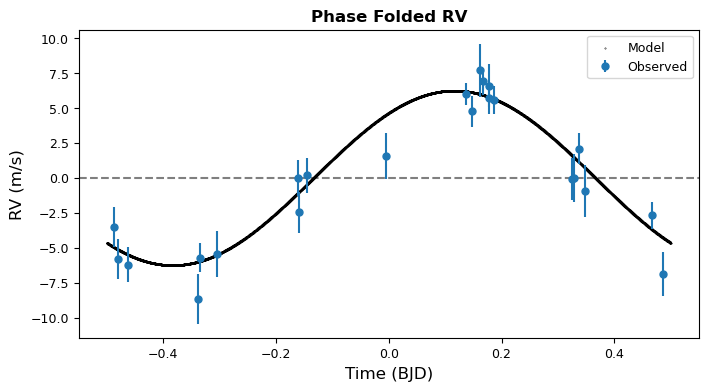

In [8]:
def plot_folded_rv():
    phase_time = ((time%period)/period)-.5
    plot_rv(phase_time)
    model_x, model_y = final_model()
    folded_model_x = ((model_x%period)/period)-.5
    plt.scatter(folded_model_x, model_y, color = 'black', s = .1, marker = 'o')
    plt.title('Phase Folded RV', fontsize = 12, fontweight = 'bold')
    plt.legend(['Model', 'Observed'])
    plt.axhline(0, linestyle = '--', alpha = .5, color = 'black')

plot_folded_rv()

In [39]:
def calc_mass():
    m1 = (period*u.day.to(u.s)*u.s)/(2*np.pi*const.G)
    m2 = k*u.m/u.s
    m3 = star['mass'][0]*u.M_sun.to(u.kg)*u.kg
    m4 = 1    #1-(eccentricity**2)
    d1 = np.sin(np.deg2rad(inclination))
    
    mass = ((m1**(1/3)) * m2 * (m3**(2/3)) * (m4**(1/2)))/d1
    mass = mass.to(u.Mearth)
    return mass

mass = calc_mass()
print(f'Mass: {round(mass, 4)}')

Mass: 17.4454 earthMass


In [38]:
def calc_density():
    volume = (4/3)*np.pi*((radius*u.Rearth.to(u.cm)*u.cm)**3)
    mass_g = mass.to(u.g)
    density = mass_g/volume

    if density.value < 3:
        composition = 'Ice/Gas'
    elif density.value < 19:
        composition = 'Iron/Rock'
    else:
        composition = 'EDM (Brown Dwarf)'
    return density, composition

density, composition = calc_density()
print(f'Density: {round(density, 4)}')
print(f'Composition: {composition}')

Density: 1.108 g / cm3
Composition: Ice/Gas
